In [1]:
# --- Imports & Alpha Vantage API Setup ---
import pandas as pd
import numpy as np
import requests
import random
import time
import os
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

ALPHA_VANTAGE_API_KEY = "NB7Z3EMLFFWRM5PN"
BASE_URL = "https://www.alphavantage.co/query"

def av_query(function, **params):
    """Query Alpha Vantage API with rate limiting."""
    params["function"] = function
    params["apikey"] = ALPHA_VANTAGE_API_KEY
    resp = requests.get(BASE_URL, params=params)
    resp.raise_for_status()
    data = resp.json()
    # Check for rate limit message
    if "Note" in data or "Information" in data:
        print(f"Rate limit hit. Waiting 60s...")
        time.sleep(60)
        resp = requests.get(BASE_URL, params=params)
        data = resp.json()
    return data

# Cache directory for storing pulled data locally
CACHE_DIR = "av_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

print("Imports loaded. Alpha Vantage API ready.")

Imports loaded. Alpha Vantage API ready.


In [2]:
# --- Load Russell 3000 Tickers from CSV (excluding Energy sector) ---
df_tickers = pd.read_csv("Tickers.csv")
df_tickers = df_tickers[df_tickers["Sector"] != "Energy"]
Tickers = df_tickers["Ticker"].dropna().astype(str).str.strip().tolist()

print(f"Loaded {len(Tickers)} tickers (Energy excluded)")

# IMPORTANT: Alpha Vantage free tier = 25 requests/day
# Each ticker needs 2 API calls (daily prices + balance sheet)
# So we can only process ~12 tickers per day on the free tier.
# Set BATCH_SIZE to control how many tickers to pull per run.
BATCH_SIZE = 10
sample_tickers = random.sample(Tickers, min(BATCH_SIZE, len(Tickers)))

print(f"\nProcessing batch of {len(sample_tickers)} tickers:")
print(sample_tickers)

Loaded 2437 tickers (Energy excluded)

Processing batch of 10 tickers:
['PL', 'NLOP', 'FCPT', 'CFG', 'GNW', 'DNTH', 'HPE', 'AMWD', 'VAC', 'TSBK']


In [3]:
# --- Pull Daily Prices + Balance Sheet from Alpha Vantage ---
# Results are cached locally so you don't burn API calls on re-runs

cutoff = datetime.now() - timedelta(days=2*365)
prices_dict = {}
equity_dict = {}
errors = []

for i, ticker in enumerate(sample_tickers):
    print(f"[{i+1}/{len(sample_tickers)}] {ticker}...", end=" ")
    
    price_cache = os.path.join(CACHE_DIR, f"{ticker}_prices.csv")
    balance_cache = os.path.join(CACHE_DIR, f"{ticker}_balance.json")
    
    # --- Daily Prices ---
    if os.path.exists(price_cache):
        df_p = pd.read_csv(price_cache, index_col=0, parse_dates=True)
        print("prices(cached)", end=" ")
    else:
        try:
            data = av_query("TIME_SERIES_DAILY", symbol=ticker, outputsize="full")
            ts_key = "Time Series (Daily)"
            if ts_key not in data:
                print(f"SKIP (no price data)")
                errors.append((ticker, "no price data"))
                continue
            df_p = pd.DataFrame(data[ts_key]).T
            df_p.index = pd.to_datetime(df_p.index)
            df_p = df_p.sort_index()
            df_p.columns = [c.split(". ")[1] for c in df_p.columns]  # "4. close" -> "close"
            df_p = df_p.astype(float)
            df_p.to_csv(price_cache)
            print("prices(API)", end=" ")
            time.sleep(12)  # rate limit: 5 calls/min
        except Exception as e:
            print(f"SKIP (price error: {e})")
            errors.append((ticker, str(e)))
            continue
    
    # Filter to 2 years
    df_p = df_p[df_p.index >= cutoff]
    prices_dict[ticker] = df_p["close"]
    
    # --- Balance Sheet ---
    if os.path.exists(balance_cache):
        with open(balance_cache) as f:
            balance_data = json.load(f)
        print("balance(cached)")
    else:
        try:
            balance_data = av_query("BALANCE_SHEET", symbol=ticker)
            if "quarterlyReports" not in balance_data:
                print(f"SKIP (no balance data)")
                errors.append((ticker, "no balance data"))
                continue
            with open(balance_cache, "w") as f:
                json.dump(balance_data, f)
            print("balance(API)")
            time.sleep(12)
        except Exception as e:
            print(f"SKIP (balance error: {e})")
            errors.append((ticker, str(e)))
            continue
    
    # Extract Total Equity from quarterly reports
    reports = balance_data["quarterlyReports"]
    eq_series = {}
    for r in reports:
        date = pd.to_datetime(r["fiscalDateEnding"])
        te = r.get("totalShareholderEquity", r.get("totalStockholderEquity", "None"))
        if te not in ["None", None, "0"]:
            eq_series[date] = float(te)
    equity_dict[ticker] = pd.Series(eq_series).sort_index()

print(f"\nDone. Got prices for {len(prices_dict)} tickers, equity for {len(equity_dict)} tickers.")
if errors:
    print(f"Errors: {errors}")

[1/10] PL... Rate limit hit. Waiting 60s...
SKIP (no price data)
[2/10] NLOP... Rate limit hit. Waiting 60s...
SKIP (no price data)
[3/10] FCPT... Rate limit hit. Waiting 60s...
SKIP (no price data)
[4/10] CFG... Rate limit hit. Waiting 60s...


KeyboardInterrupt: 

In [ ]:
# --- Calculate Daily Price-to-Book ---
# P/B = (Price * Shares) / Total Equity
# Since Alpha Vantage daily prices don't include shares outstanding,
# we use the OVERVIEW endpoint for current shares, or approximate:
# P/B ≈ Price / (Total Equity / Shares) = Price / Book Value Per Share
# But simpler: we pull shares from OVERVIEW and compute Market Cap

# Actually, let's just use Price / (Equity per share) approach:
# Pull shares outstanding from OVERVIEW for each ticker

shares_dict = {}
for ticker in prices_dict.keys():
    overview_cache = os.path.join(CACHE_DIR, f"{ticker}_overview.json")
    if os.path.exists(overview_cache):
        with open(overview_cache) as f:
            overview = json.load(f)
    else:
        overview = av_query("OVERVIEW", symbol=ticker)
        with open(overview_cache, "w") as f:
            json.dump(overview, f)
        time.sleep(12)
    
    shares = overview.get("SharesOutstanding", "None")
    if shares not in ["None", None, "0", ""]:
        shares_dict[ticker] = float(shares)

print(f"Got shares outstanding for {len(shares_dict)} tickers")

# Build P/B DataFrame
pb_data = {}
for ticker in prices_dict.keys():
    if ticker not in equity_dict or ticker not in shares_dict:
        continue
    
    price = prices_dict[ticker]
    shares = shares_dict[ticker]
    equity_q = equity_dict[ticker]
    
    # Forward-fill quarterly equity onto daily dates
    all_dates = equity_q.index.union(price.index).sort_values()
    equity_daily = equity_q.reindex(all_dates, method="ffill").reindex(price.index)
    
    # P/B = (Price * Shares Outstanding) / Total Equity
    mktcap = price * shares
    pb = mktcap / equity_daily
    pb_data[ticker] = pb

pb_df = pd.DataFrame(pb_data)
pb_df = pb_df.replace([np.inf, -np.inf], np.nan)

print(f"\nP/B computed for {pb_df.shape[1]} tickers over {pb_df.shape[0]} trading days")
print(f"Non-null values: {pb_df.count().sum()} / {pb_df.size}")
print(f"Date range: {pb_df.index.min()} to {pb_df.index.max()}")
pb_df.head()

Got shares outstanding for 0 tickers

P/B computed for 0 tickers over 0 trading days
Non-null values: 0 / 0
Date range: nan to nan


""


/var/folders/d2/5t83298d0vq9j63x6c791_040000gn/T/ipykernel_25815/280479616.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=11)


ValueError: no types given

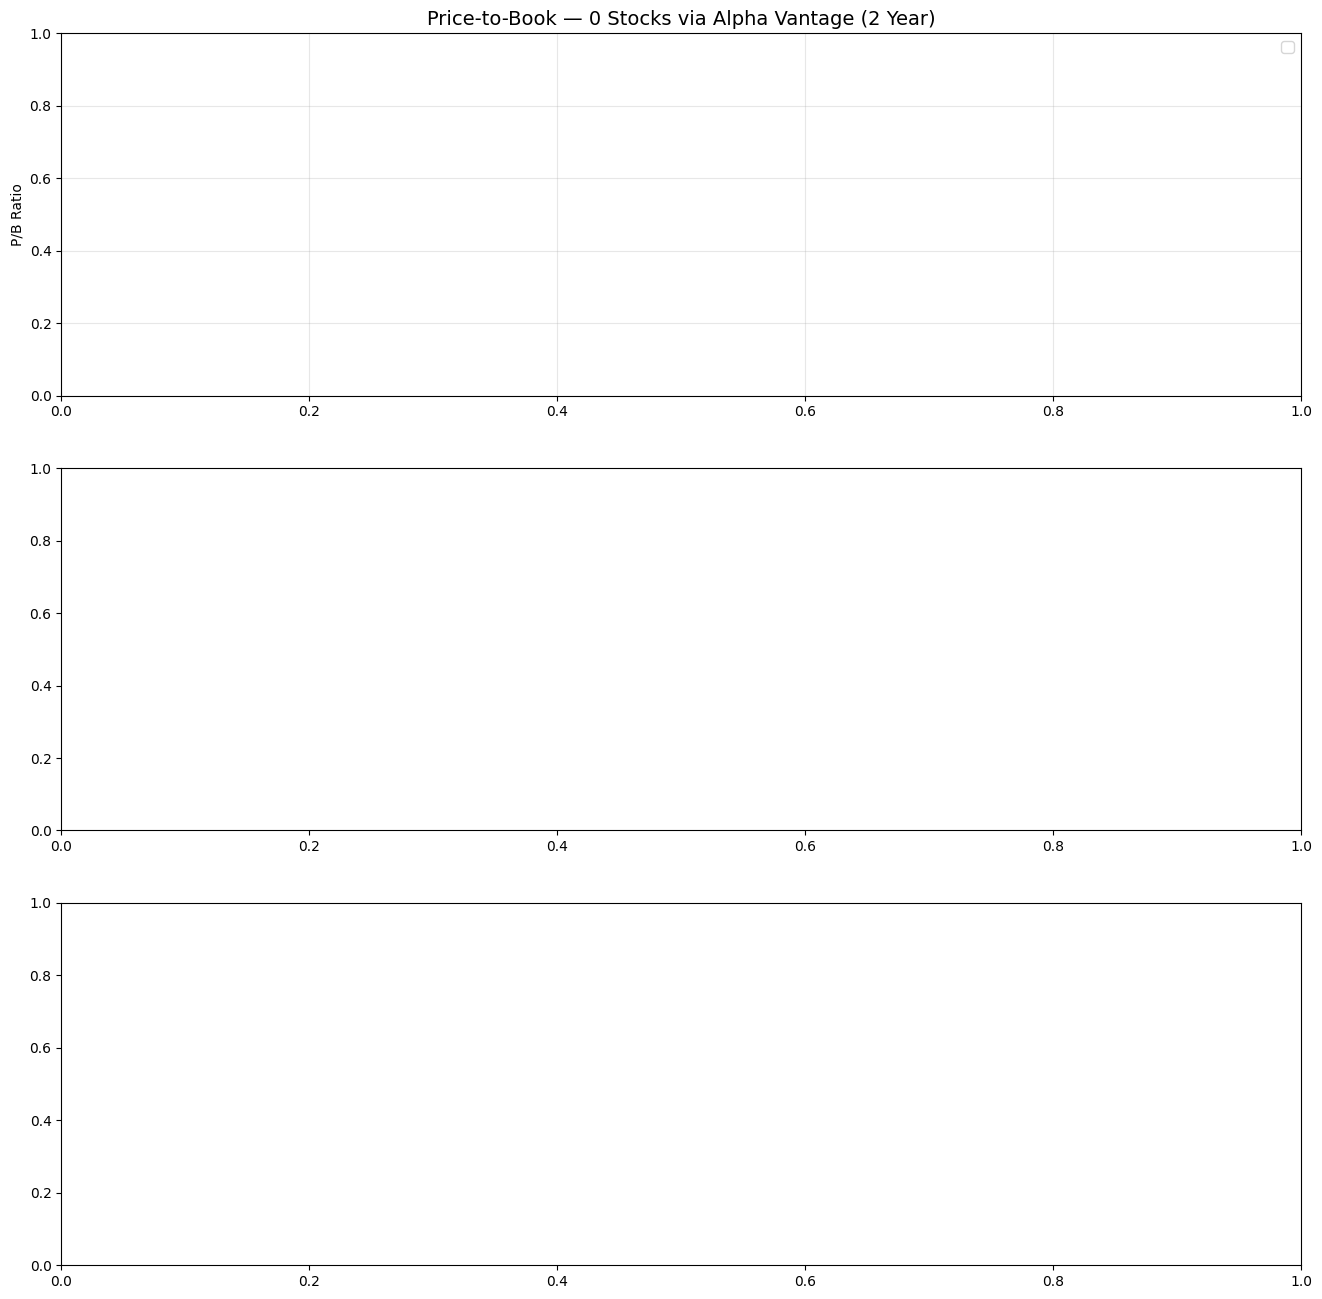

In [ ]:
# --- Plot Price-to-Book Ratios ---

# Pick up to 5 tickers that have data
valid_tickers = pb_df.columns[pb_df.notna().sum() > 50].tolist()
plot_tickers = random.sample(valid_tickers, min(5, len(valid_tickers)))

fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# Plot 1: Individual tickers
ax1 = axes[0]
for t in plot_tickers:
    ax1.plot(pb_df.index, pb_df[t], linewidth=1.5, label=t)
ax1.set_title(f"Price-to-Book — {len(plot_tickers)} Stocks via Alpha Vantage (2 Year)", fontsize=14)
ax1.set_ylabel("P/B Ratio")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Median P/B with interquartile range
ax2 = axes[1]
median_pb = pb_df.median(axis=1)
q25_pb = pb_df.quantile(0.25, axis=1)
q75_pb = pb_df.quantile(0.75, axis=1)
ax2.fill_between(median_pb.index, q25_pb, q75_pb, alpha=0.2, color="steelblue", label="25th-75th percentile")
ax2.plot(median_pb.index, median_pb, color="steelblue", linewidth=2, label="Median P/B")
ax2.set_title(f"Median Price-to-Book — {pb_df.shape[1]} Stocks (2 Year)", fontsize=14)
ax2.set_ylabel("P/B Ratio")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of current P/B values
ax3 = axes[2]
current_pb = pb_df.iloc[-1].dropna()
current_pb_clipped = current_pb[(current_pb > 0) & (current_pb < 20)]
if len(current_pb_clipped) > 0:
    ax3.hist(current_pb_clipped, bins=max(10, len(current_pb_clipped)//2), color="steelblue", edgecolor="white", alpha=0.8)
    ax3.axvline(current_pb_clipped.median(), color="red", linestyle="--", linewidth=2, label=f"Median: {current_pb_clipped.median():.2f}")
ax3.set_title("Current P/B Distribution", fontsize=14)
ax3.set_xlabel("P/B Ratio")
ax3.set_ylabel("Number of Stocks")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTickers shown: {plot_tickers}")
print(f"\nSummary Stats (current P/B):")
print(current_pb.describe().round(2))

In [ ]:
# --- Data Quality Check ---

coverage = pb_df.notna().sum() / pb_df.shape[0] * 100

good = coverage[coverage >= 90]
partial = coverage[(coverage >= 50) & (coverage < 90)]
sparse = coverage[(coverage > 0) & (coverage < 50)]
zero = coverage[coverage == 0]

print(f"=== P/B Data Coverage ({pb_df.shape[0]} trading days) ===")
print(f"  Good (>=90%):    {len(good)} tickers")
print(f"  Partial (50-90%): {len(partial)} tickers")
print(f"  Sparse (<50%):   {len(sparse)} tickers")
print(f"  No data (0%):    {len(zero)} tickers")

print(f"\n=== Per-Ticker Coverage ===")
for t in pb_df.columns:
    pct = coverage[t]
    has_prices = ticker in prices_dict
    has_equity = ticker in equity_dict
    has_shares = ticker in shares_dict
    print(f"  {t:6s}: {pct:.0f}% coverage")

print(f"\n=== Note ===")
print(f"Alpha Vantage free tier: 25 requests/day, 5 requests/min")
print(f"Each ticker needs ~3 API calls (prices + balance sheet + overview)")
print(f"Cached data is in ./av_cache/ — delete cache files to re-pull")
print(f"To process more tickers, increase BATCH_SIZE in cell 2 and re-run")
print(f"Run this notebook daily to accumulate more tickers over time")